### **Import the required packages**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

### **Reading and Exploring the Data**

1. import the data from a csv file to a dataframe.
2. check for the shape of the data.
3. check for datatypes of values in each column.
4. check for missing values column-wise and remove those.
5. check for duplicate rows in the data and remove those.
6. check for outlier and clean them.
7. Encoding of the categorical columns.


In [ ]:
customers = pd.read_csv('Mall_Customers.csv')

In [ ]:
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
customers.shape #print the total number of rows and columns

(200, 5)

In [ ]:
customers.drop(columns = 'CustomerID', inplace = True) #drop the CustomerID column as it was useless

In [ ]:
customers.isnull().sum() #print the total number of missing values

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
customers.duplicated().sum()  #print the total number of rows which are duplicates

np.int64(0)

In [ ]:
customers.drop_duplicates(inplace = True) #drop the duplicate rows

#### **Encode the Gender column using LabelEncoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

customers['Gender'] = le.fit_transform(customers['Gender'])

### **Machine Learning Process**

In [ ]:
X = customers.values  #".values" will convert your customers dataframe into an array

#### **Process of calculating wcss values for identifying the optimal k-value.**

In [ ]:
wcss = []

for k in range(1, 10):
  kmeans = KMeans(n_clusters = k, init = 'k-means++')
  kmeans.fit(X) #Start making the clusters and divide our datapoint in those clusters

  print(kmeans.inertia_)  #'inertia_ is storing the wcss values'
  wcss.append(kmeans.inertia_)

308862.06000000006
212889.44245524294
169090.62656250008
104434.82333370825
75542.77371510216
58350.654494628165
51201.740785418966
44389.80767355767
42868.677886321195


#### **Plotting the k-values and their corresponding WCSS values**

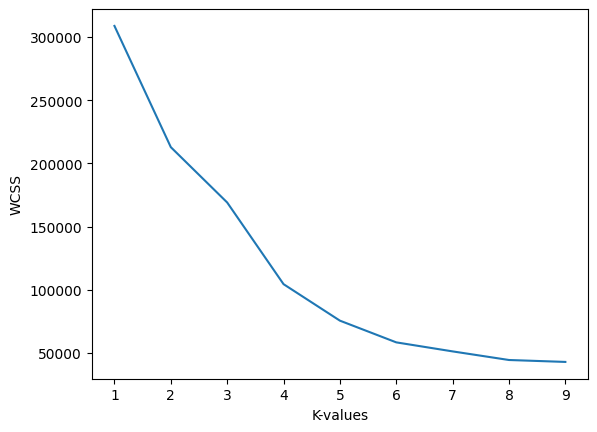

In [ ]:
plt.plot(range(1, 10), wcss)
plt.xlabel('K-values')
plt.ylabel('WCSS')
plt.show()

#### **Apply KMeans algorithm on the data(X)**

In [ ]:
kmeans = KMeans(n_clusters = 6, init = 'k-means++')
kmeans.fit(X)

KMeans(n_clusters=6)

In [ ]:
y = kmeans.predict(X) #

In [ ]:
y

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 5, 3, 4, 2,
       4, 3, 5, 2, 2, 2, 5, 2, 2, 5, 5, 5, 5, 5, 2, 5, 5, 2, 5, 5, 5, 2,
       5, 5, 2, 2, 5, 5, 5, 5, 5, 2, 5, 2, 2, 5, 5, 2, 5, 5, 2, 5, 5, 2,
       2, 5, 5, 2, 5, 2, 2, 2, 5, 2, 5, 2, 2, 5, 5, 2, 5, 2, 5, 5, 5, 5,
       5, 2, 2, 2, 2, 2, 5, 5, 5, 5, 2, 2, 2, 0, 2, 0, 1, 0, 1, 0, 1, 0,
       2, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0], dtype=int32)

In [ ]:
output = pd.DataFrame(y, columns = ['Cluster Number'])

In [ ]:
output

,Cluster Number
0,4
1,3
2,4
3,3
4,4
...,...
195,0
196,1
197,0
198,1


In [ ]:
final_df = pd.concat([customers, output], axis = 1)

In [ ]:
final_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster Number
0,1,19,15,39,4
1,1,21,15,81,3
2,0,20,16,6,4
3,0,23,16,77,3
4,0,31,17,40,4
